In [67]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import os



In [69]:
df = pd.read_csv("data_clean/prediction_df.csv")

In [31]:
df

,Unnamed: 0,Past_vote,Year,country,Urban,Q62,Ukraine_groups,Woman,Education
0,1,139,2025,Croatia,Urban,5,Domestic/ Distracted,Man,Tertiary
1,2,141,2025,Croatia,Rural,5,Russia collaboration,Man,Tertiary
2,3,139,2025,Croatia,Suburban,5,Russia collaboration,Man,Tertiary
3,4,323,2025,Croatia,Urban,2,Domestic/ Distracted,Woman,Higher Secondary
4,5,139,2025,Croatia,Rural,4,Russia collaboration,Woman,Higher Secondary
...,...,...,...,...,...,...,...,...,...
38094,38095,79,2023,Sweden,Rural,3,Domestic/ Distracted,Woman,Tertiary
38095,38096,74,2023,Sweden,Suburban,4,Domestic/ Distracted,Woman,Tertiary
38096,38097,74,2023,Sweden,Rural,6,Domestic/ Distracted,Woman,Higher Secondary
38097,38098,75,2023,Sweden,Urban,5,Domestic/ Distracted,Man,Tertiary


In [12]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
df.columns = ['sl', 'sw', 'pl', 'pw', 'target']

In [6]:
setosa=df[df['target'] == 0]
versicolour=df[df['target'] == 1]
virginaca=df[df['target'] == 2]

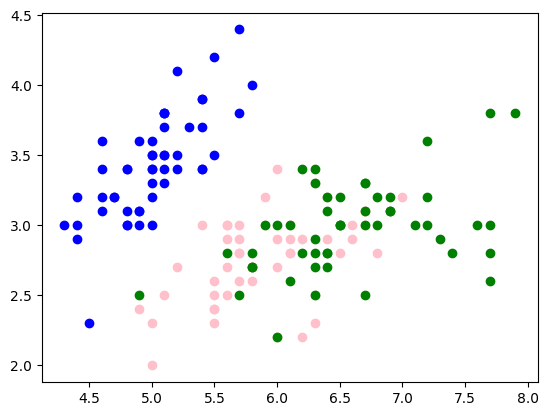

In [7]:
plt.scatter(setosa['sl'], setosa['sw'], color = 'blue')
plt.scatter(versicolour['sl'], versicolour['sw'], color = 'pink')
plt.scatter(virginaca['sl'], virginaca['sw'], color = 'green')

In [8]:
train, test = train_test_split(df, test_size=0.2)
trainX = train[['sl', 'sw', 'pl', 'pw']]
trainY = train[['target']]
testX = test[['sl', 'sw', 'pl', 'pw']]
testY = test[['target']]

In [12]:
import sklearn
print(sklearn.__version__)


1.8.0


In [13]:
LR = LogisticRegression(max_iter=1000).fit(trainX, trainY)

/Users/rafaelc-g/miniconda3/envs/r-bertopic/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [15]:
confusion_matrix(testY, LR.predict(testX))

array([[11,  0,  0],
       [ 0, 11,  1],
       [ 0,  1,  6]])

In [16]:
print(classification_report(testY,LR.predict(testX)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.92      0.92      0.92        12
           2       0.86      0.86      0.86         7

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



In [32]:

categorical = ['Ukraine_groups', 'Urban', 'Woman', 'Education']
numeric = ['Q62', 'Year']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical),
        ('num', 'passthrough', numeric)
    ]
)

model = Pipeline([
    ('prep', preprocess),
    ('logit', LogisticRegression(max_iter=1000))
])

In [ ]:
df.Ukraine_groups

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)


# ----------------------------
# PREPROCESSING
# ----------------------------
def prep_X(train, test, cols):
    X_train = pd.get_dummies(train[cols], drop_first=True)
    X_test = pd.get_dummies(test[cols], drop_first=True)

    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
    return X_train, X_test


# ----------------------------
# FP / FN METRICS (binary only)
# ----------------------------
def get_fp_fn_rates(y_true, y_pred):

    labels = sorted(pd.unique(y_true))

    if len(labels) != 2:
        return {
            "TP": None,
            "FP": None,
            "TN": None,
            "FN": None,
            "precision": None,
            "recall": None,
            "fpr": None,
            "accuracy": accuracy_score(y_true, y_pred)
        }

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()

    return {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else None,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else None,
        "fpr": fp / (fp + tn) if (fp + tn) > 0 else None,
        "accuracy": accuracy_score(y_true, y_pred)
    }


# ----------------------------
# MAIN FUNCTION
# ----------------------------
def test_train_model(country):

    temp = df[df['country'] == country]

    train, test = train_test_split(temp, test_size=0.2, random_state=1998)

    y_train = train['Past_vote']
    y_test = test['Past_vote']

    os.makedirs("classification/reports", exist_ok=True)
    os.makedirs("classification/cm", exist_ok=True)

    specs = {
        "Ideology": ['Q62', 'Year','Woman', 'Education'],
        "Ideology + Urban": ['Q62', 'Urban', 'Year','Woman', 'Education'],
        "Group": ['Ukraine_groups', 'Year','Woman', 'Education'],
        "Ideology + Urban + Group": ['Ukraine_groups', 'Q62', 'Urban', 'Year','Woman', 'Education']
    }

    results = []

    for name, cols in specs.items():

        X_train, X_test = prep_X(train, test, cols)

        model = LogisticRegression(max_iter=100000)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        # -----------------------
        # classification report
        # -----------------------
        report = classification_report(y_test, preds)

        with open(f"classification/reports/report_{country}_{name}.txt", "w") as f:
            f.write(report)

        # -----------------------
        # confusion matrix plot
        # -----------------------
        cm = confusion_matrix(y_test, preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)

        disp.plot()
        plt.title(f"{country} - {name}")
        plt.savefig(f"classification/cm/cm_{country}_{name}.png")
        plt.close()

        # -----------------------
        # metrics table row
        # -----------------------
        metrics = get_fp_fn_rates(y_test, preds)

        metrics.update({
            "country": country,
            "model": name
        })

        results.append(metrics)

    return pd.DataFrame(results)

In [64]:
all_results = pd.concat(
    [test_train_model(c) for c in df['country'].unique()],
    ignore_index=True
)

/Users/rafaelc-g/miniconda3/envs/r-bertopic/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rafaelc-g/miniconda3/envs/r-bertopic/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rafaelc-g/miniconda3/envs/r-bertopic/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [65]:
all_results

,TP,FP,TN,FN,precision,recall,fpr,accuracy,country,model
0,None,None,None,None,None,None,None,0.466063,Croatia,Ideology
1,None,None,None,None,None,None,None,0.475113,Croatia,Ideology + Urban
2,None,None,None,None,None,None,None,0.321267,Croatia,Group
3,None,None,None,None,None,None,None,0.493213,Croatia,Ideology + Urban + Group
4,None,None,None,None,None,None,None,0.195326,Denmark,Ideology
...,...,...,...,...,...,...,...,...,...,...
83,None,None,None,None,None,None,None,0.406091,Ireland,Ideology + Urban + Group
84,None,None,None,None,None,None,None,0.528169,Portugal,Ideology
85,None,None,None,None,None,None,None,0.485915,Portugal,Ideology + Urban
86,None,None,None,None,None,None,None,0.394366,Portugal,Group


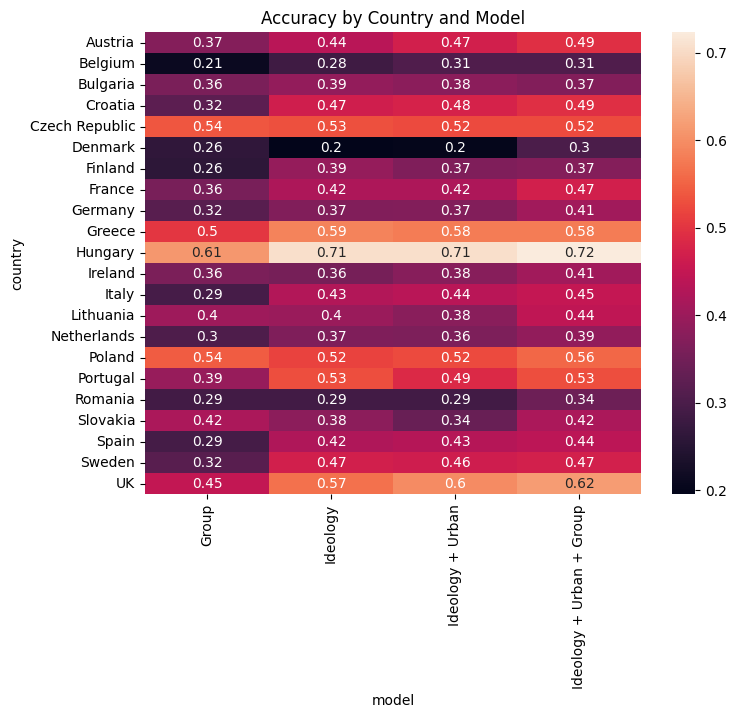

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy heatmap
pivot_acc = all_results.pivot(index="country", columns="model", values="accuracy")

plt.figure(figsize=(8,6))
sns.heatmap(pivot_acc, annot=True)
plt.title("Accuracy by Country and Model")
plt.show()

In [70]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)


# ----------------------------
# PREPROCESSING
# ----------------------------
def prep_X(train, test, cols):
    X_train = pd.get_dummies(train[cols], drop_first=True)
    X_test = pd.get_dummies(test[cols], drop_first=True)

    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
    return X_train, X_test


# ----------------------------
# MAIN FUNCTION
# ----------------------------
def test_train_model(country):

    temp = df[df['country'] == country]

    train, test = train_test_split(temp, test_size=0.2, random_state=1998)

    y_train = train['Past_vote']
    y_test = test['Past_vote']

    os.makedirs("classification/reports_factor", exist_ok=True)
    os.makedirs("classification/cm_factor", exist_ok=True)

    specs = {
        "Ideology": ['Q62', 'Year','Woman', 'Education'],
        "Ideology + Urban": ['Q62', 'Urban', 'Year','Woman', 'Education'],
        "Group": ['Security_FA', 'Year','Woman', 'Education'],
        "Ideology + Urban + Group": ['Security_FA', 'Q62', 'Urban', 'Year','Woman', 'Education']
    }

    results = []

    for name, cols in specs.items():

        X_train, X_test = prep_X(train, test, cols)

        model = LogisticRegression(max_iter=100000)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        # -----------------------
        # classification report
        # -----------------------
        report = classification_report(y_test, preds)

        with open(f"classification/reports/report_{country}_{name}.txt", "w") as f:
            f.write(report)

        # -----------------------
        # confusion matrix plot
        # -----------------------
        cm = confusion_matrix(y_test, preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)

        disp.plot()
        plt.title(f"{country} - {name}")
        plt.savefig(f"classification/cm/cm_{country}_{name}.png")
        plt.close()

        # -----------------------
        # metrics table row
        # -----------------------
        metrics = {"accuracy": accuracy_score(y_test, preds)}

        metrics.update({
            "country": country,
            "model": name
        })

        results.append(metrics)

    return pd.DataFrame(results)

In [71]:
all_results_factor = pd.concat(
    [test_train_model(c) for c in df['country'].unique()],
    ignore_index=True
)

/Users/rafaelc-g/miniconda3/envs/r-bertopic/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rafaelc-g/miniconda3/envs/r-bertopic/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rafaelc-g/miniconda3/envs/r-bertopic/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

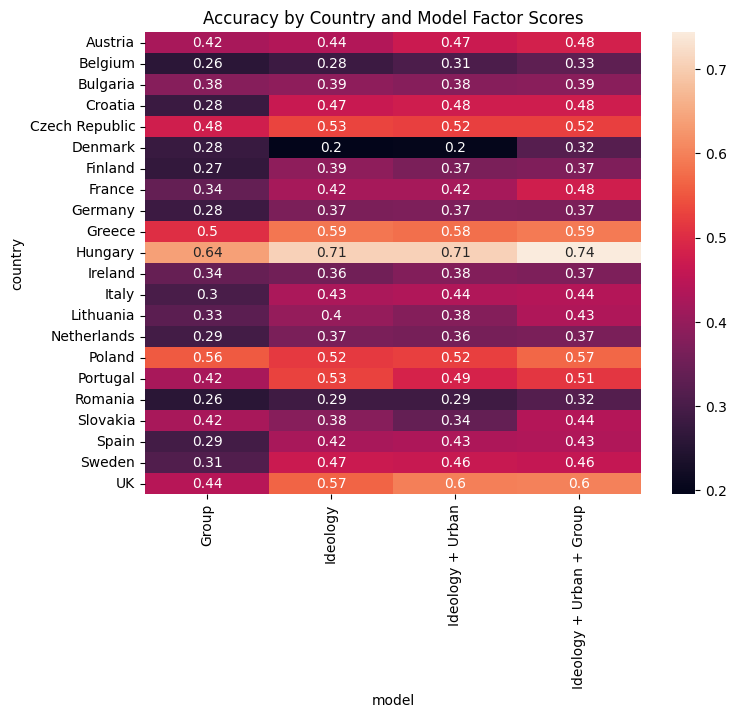

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy heatmap
pivot_acc = all_results_factor.pivot(index="country", columns="model", values="accuracy")

plt.figure(figsize=(8,6))
sns.heatmap(pivot_acc, annot=True)
plt.title("Accuracy by Country and Model Factor Scores")
plt.show()